In [1]:
!pip install simpy xgboost

In [2]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor

In [3]:
def queue_simulation(arrival_rate, service_rate, num_servers, sim_time):
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=num_servers)

    wait_times = []

    def customer(env):
        arrival_time = env.now

        with server.request() as request:
            yield request
            wait_times.append(env.now - arrival_time)
            service_time = random.expovariate(service_rate)
            yield env.timeout(service_time)

    def arrival_process(env):
        while True:
            inter_arrival = random.expovariate(arrival_rate)
            yield env.timeout(inter_arrival)
            env.process(customer(env))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    if len(wait_times) == 0:
        return 0
    return np.mean(wait_times)

In [4]:
data = []

for i in range(1000):
    arrival_rate = random.uniform(1, 20)
    service_rate = random.uniform(1, 25)
    num_servers = random.randint(1, 5)
    sim_time = random.randint(200, 1000)

    avg_wait = queue_simulation(arrival_rate, service_rate, num_servers, sim_time)

    data.append([arrival_rate, service_rate, num_servers, sim_time, avg_wait])

df = pd.DataFrame(data, columns=[
    "arrival_rate", "service_rate", "num_servers", "sim_time", "avg_wait_time"
])

df.head()

,arrival_rate,service_rate,num_servers,sim_time,avg_wait_time
0,15.863691,20.555756,5,720,0.000008
1,18.538153,13.567329,2,800,0.070168
2,5.292940,18.600005,1,814,0.022117
3,16.847369,10.408593,3,440,0.017482
4,4.337924,15.235585,3,492,0.000050


In [6]:
from google.colab import files
df.to_csv("simulation_dataset.csv", index=False)
files.download("simulation_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
X = df.drop("avg_wait_time", axis=1)
y = df["avg_wait_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "MLP": MLPRegressor(max_iter=1000),
    "XGBoost": XGBRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
7,XGBoost,10.673081,24.728365,0.880570
6,MLP,16.316091,28.822371,0.837752
2,Random Forest,13.675177,31.361113,0.807910
1,Decision Tree,13.733324,37.772117,0.721347
3,Gradient Boosting,20.805280,40.441348,0.680572
0,Linear Regression,37.818327,55.866466,0.390430
4,KNN,28.665993,61.390763,0.263916
5,SVR,28.836224,77.089654,-0.160682


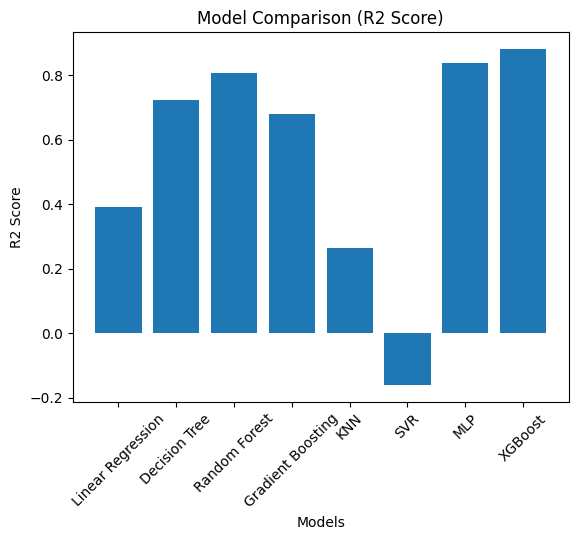

In [9]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

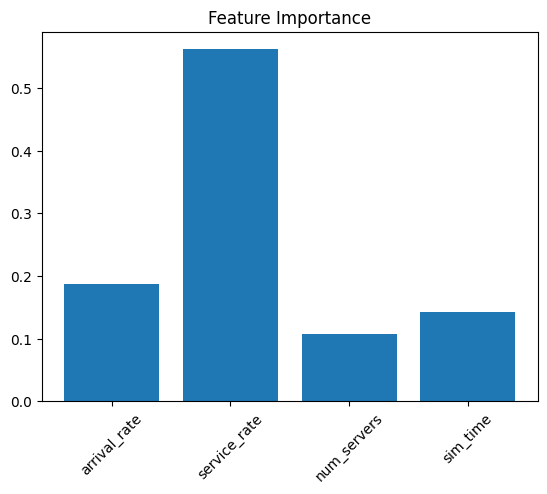

In [10]:
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

importances = best_model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()